#### Loading Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
# pd.set_option('max_columns', 200)

In [2]:
df = pd.read_csv("Unemployment in India.csv")


In [3]:
df.shape

(768, 7)

### 1. Data cleaning

In [4]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [6]:
df.isnull().all(axis=1).sum()

np.int64(28)

In [7]:
df.columns = df.columns.str.strip()
df.columns



Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [8]:
df = df.dropna(how='all')

In [9]:
df.isnull().sum()

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64

In [10]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 46.2+ KB


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [14]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.month_name()

In [17]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month,Month_Name
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,May
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6,June
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7,July
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8,August
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9,September


### EDA Questions

#### Unemployment Rate Questions
###### 1.Did unemployment increase during COVID?
###### 2.Which month had the highest unemployment?
###### 3.Which regions were most affected?
###### 4.Which area has higher unemployment between urban and rural?
###### 5.Did unemployment recover?





### 1.Did unemployment increase during COVID?

In [ ]:
#group by year
df.groupby('Year')['Estimated Unemployment Rate (%)'].mean()


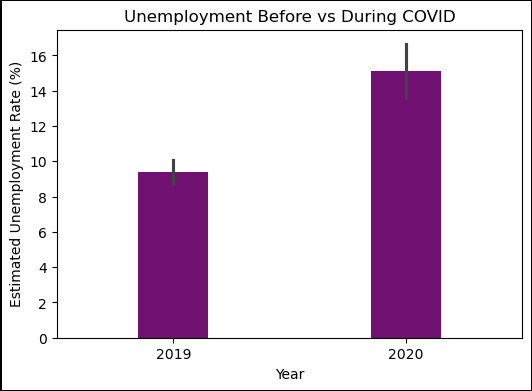

In [34]:
plt.figure(figsize=(6,4),facecolor='white', edgecolor='black',linewidth=2)
sns.barplot(x='Year', y='Estimated Unemployment Rate (%)', data=df,color='purple',width=0.3)
plt.title("Unemployment Before vs During COVID")
plt.savefig('Unemployment Before vs During COVID.png')
plt.show()

In [ ]:
# 2020 > 2019 → increase of unemployment during COVID

### 2.Which month had the highest unemployment?

In [20]:
monthly_unemployment = df.groupby('Month_Name')['Estimated Unemployment Rate (%)'].mean()

In [21]:
monthly_unemployment.sort_values(ascending=False)

Month_Name
April        23.641569
May          16.646190
March        10.700577
June         10.553462
February      9.964717
January       9.950755
October       9.900909
November      9.868364
August        9.637925
December      9.497358
September     9.051731
July          9.033889
Name: Estimated Unemployment Rate (%), dtype: float64

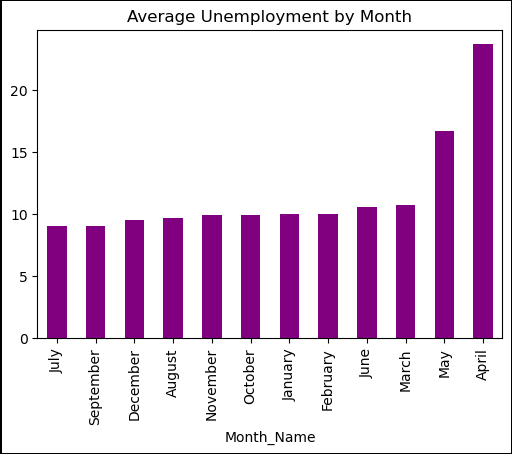

In [33]:
plt.figure(facecolor='white', edgecolor='black',linewidth=2,figsize=(6,4))
monthly_unemployment.sort_values().plot(kind='bar',color='purple')
plt.title("Average Unemployment by Month",color='black')
plt.savefig('Average Unemployment by Month.png')
plt.show()

In [ ]:
# April has the highest rate of unemployment.

### 3.Which regions were most affected?

In [23]:
region_unemployment = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

In [24]:
region_unemployment.sort_values(ascending=False)

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

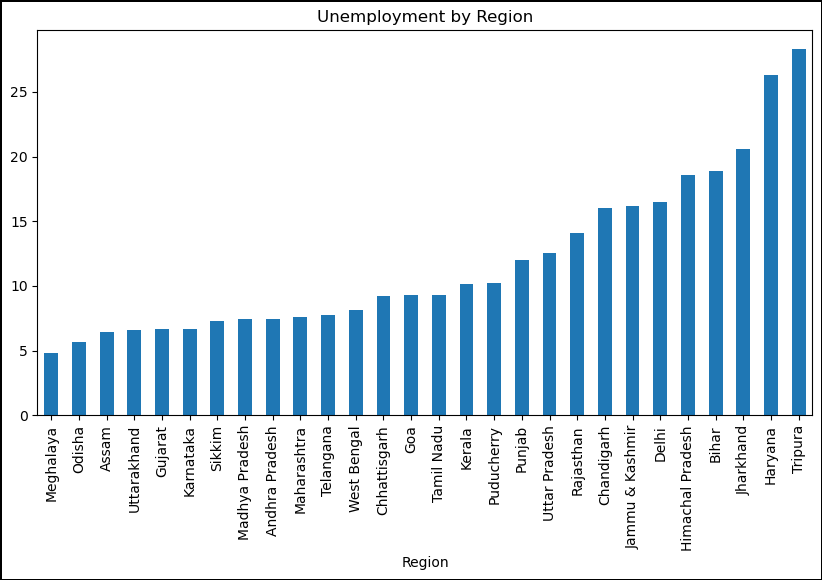

In [31]:
plt.figure(facecolor='white', edgecolor='black',linewidth=2,figsize=(10,5))
region_unemployment.sort_values().plot(kind='bar')
plt.title("Unemployment by Region",color='black')
plt.savefig('Unemployment by Region.png')
plt.show()

In [ ]:
#most affected region = Tripura
#least affected = Meghalaya

### 4.Rural vs Urban impact?¶

In [26]:
df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64

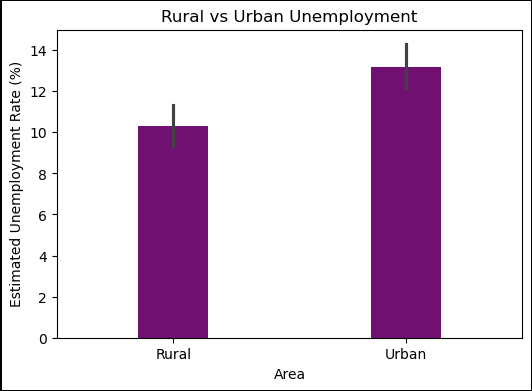

In [30]:
plt.figure(figsize=(6,4),facecolor='white', edgecolor='black',linewidth=2)
sns.barplot(x='Area', y='Estimated Unemployment Rate (%)', data=df,width=0.3,color='purple')
plt.title("Rural vs Urban Unemployment")
plt.savefig('Rural vs Urban impact.png')
plt.show()

In [ ]:
#Which area has higher unemployment = Urban


### 5.Did unemployment recover?

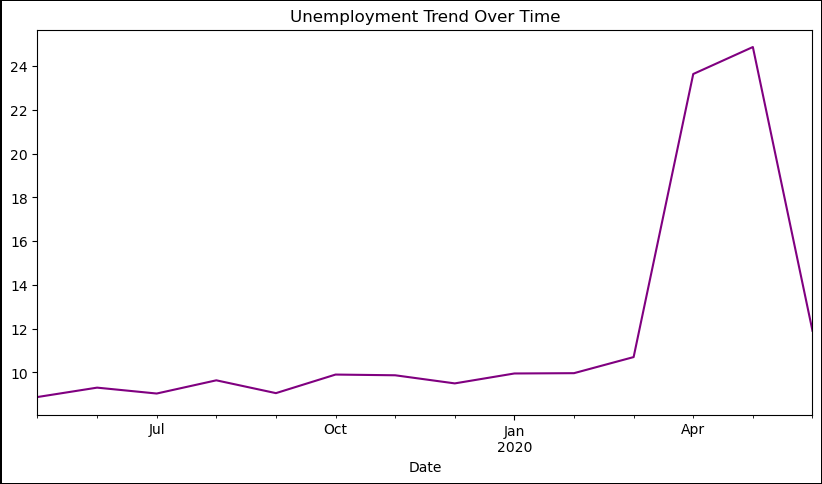

In [28]:
plt.figure(facecolor='white', edgecolor='black',linewidth=2)
df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().plot(figsize=(10,5),color='purple')
plt.title("Unemployment Trend Over Time")
plt.savefig("Unemployment_Trend_Over_Time.png")
plt.show()

In [ ]:
# After the peak rise of unemployment during lockdown, we saw a drop in unemployment after lockdown.

# Conclusion and Findings

1. Unemployment increased significantly in 2020 compared to 2019 due to the COVID-19 pandemic.

2. The highest unemployment spike occurred in April 2020 during the lockdown period.

3. Tripura recorded the highest unemployment rate, while Meghalaya recorded the lowest.

4. Urban areas experienced higher unemployment rates than rural areas.

5. After the lockdown period, unemployment rates gradually declined, indicating economic recovery.